In [4]:
# Cell 1 — Import libraries and load data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load our scraped data
df = pd.read_csv('../data/jobs_raw.csv')

# First look
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 3 rows:")
df.head(3)

Shape: (125, 9)

Columns: ['title', 'company', 'location', 'region', 'employment_type', 'job_id', 'posted_date', 'apply_url', 'scraped_at']

First 3 rows:


,title,company,location,region,employment_type,job_id,posted_date,apply_url,scraped_at
0,Data Scientist,Vodafone GmbH,Unterföhring,Bayern,NaN,17102-44108724-529-S,2026-06-01,https://www.arbeitsagentur.de/jobsuche/jobdeta...,2026-06-06 22:29:40
1,Data Scientist,ASC Technologies AG,Hösbach,Bayern,NaN,10001-1003123827-S,2026-05-28,https://www.arbeitsagentur.de/jobsuche/jobdeta...,2026-06-06 22:29:40
2,Data Scientist,adp Merkur GmbH,"Lübbecke, Westfalen",Nordrhein-Westfalen,NaN,14820-0064559033-S,2026-05-06,https://www.arbeitsagentur.de/jobsuche/jobdeta...,2026-06-06 22:29:40


In [5]:
# Cell 2 — Data Quality Check
print("=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== BASIC STATS ===")
print(f"Total jobs: {len(df)}")
print(f"Unique companies: {df['company'].nunique()}")
print(f"Unique cities: {df['location'].nunique()}")
print(f"Unique regions: {df['region'].nunique()}")
print(f"Date range: {df['posted_date'].min()} to {df['posted_date'].max()}")

=== MISSING VALUES ===
title                0
company              0
location             6
region               4
employment_type    125
job_id               0
posted_date          0
apply_url            0
scraped_at           0
dtype: int64

=== DATA TYPES ===
title                  str
company                str
location               str
region                 str
employment_type    float64
job_id                 str
posted_date            str
apply_url              str
scraped_at             str
dtype: object

=== BASIC STATS ===
Total jobs: 125
Unique companies: 102
Unique cities: 63
Unique regions: 14
Date range: 2025-09-24 to 2026-10-01


In [6]:
# Cell 3 — Data Cleaning
# Fill missing location and region
df['location'] = df['location'].fillna('Unknown')
df['region'] = df['region'].fillna('Unknown')

# Drop employment_type for now — will extract via NLP in Phase 3
df = df.drop(columns=['employment_type'])

# Convert posted_date to proper datetime
df['posted_date'] = pd.to_datetime(df['posted_date'], errors='coerce')

print("=== AFTER CLEANING ===")
print(df.isnull().sum())
print(f"\nShape: {df.shape}")
print(f"\nDate range: {df['posted_date'].min().date()} to {df['posted_date'].max().date()}")

=== AFTER CLEANING ===
title          0
company        0
location       0
region         0
job_id         0
posted_date    0
apply_url      0
scraped_at     0
dtype: int64

Shape: (125, 8)

Date range: 2025-09-24 to 2026-10-01


C:\Users\Admin\AppData\Local\Temp\ipykernel_253784\1274709870.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette='Blues_r')


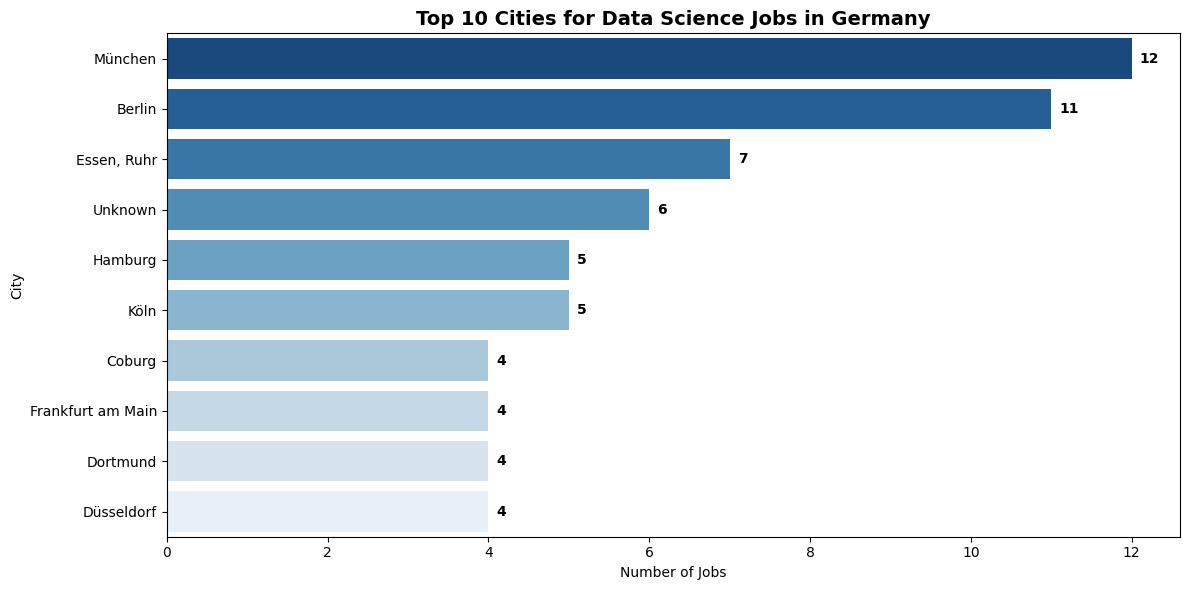


Top city: München with 12 jobs


In [7]:
# Cell 4 — Top 10 Cities for Data Science Jobs
plt.figure(figsize=(12, 6))

top_cities = df['location'].value_counts().head(10)

sns.barplot(x=top_cities.values, y=top_cities.index, palette='Blues_r')

plt.title('Top 10 Cities for Data Science Jobs in Germany', fontsize=14, fontweight='bold')
plt.xlabel('Number of Jobs')
plt.ylabel('City')

for i, v in enumerate(top_cities.values):
    plt.text(v + 0.1, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/top_cities.png', dpi=150)
plt.show()

print(f"\nTop city: {top_cities.index[0]} with {top_cities.values[0]} jobs")

C:\Users\Admin\AppData\Local\Temp\ipykernel_253784\1043345630.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_companies.values, y=top_companies.index, palette='Greens_r')


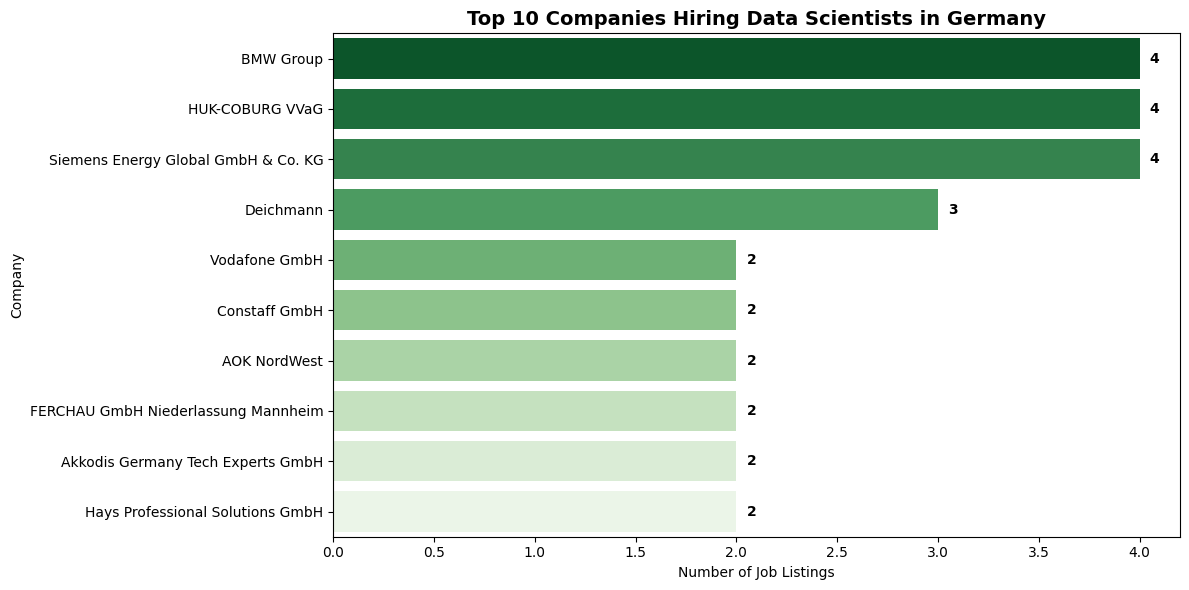


Top 10 companies:
  BMW Group: 4 jobs
  HUK-COBURG VVaG: 4 jobs
  Siemens Energy Global GmbH & Co. KG: 4 jobs
  Deichmann: 3 jobs
  Vodafone GmbH: 2 jobs
  Constaff GmbH: 2 jobs
  AOK NordWest: 2 jobs
  FERCHAU GmbH Niederlassung Mannheim: 2 jobs
  Akkodis Germany Tech Experts GmbH: 2 jobs
  Hays Professional Solutions GmbH: 2 jobs


In [8]:
# Cell 5 — Top 10 Companies Hiring Data Scientists
plt.figure(figsize=(12, 6))

top_companies = df['company'].value_counts().head(10)

sns.barplot(x=top_companies.values, y=top_companies.index, palette='Greens_r')

plt.title('Top 10 Companies Hiring Data Scientists in Germany', fontsize=14, fontweight='bold')
plt.xlabel('Number of Job Listings')
plt.ylabel('Company')

for i, v in enumerate(top_companies.values):
    plt.text(v + 0.05, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/top_companies.png', dpi=150)
plt.show()

print("\nTop 10 companies:")
for company, count in top_companies.items():
    print(f"  {company}: {count} jobs")

C:\Users\Admin\AppData\Local\Temp\ipykernel_253784\3466552633.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_regions.values, y=top_regions.index, palette=colors)


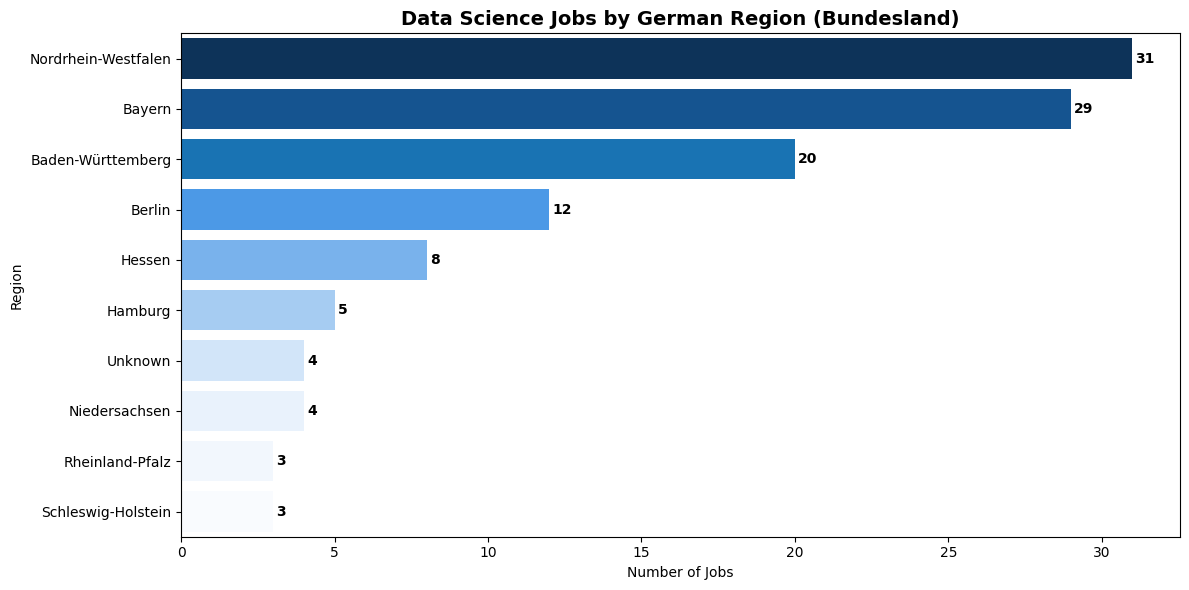


Key insight:
Top 3 regions account for 80 out of 125 jobs (64.0%)


In [9]:
# Cell 6 — Jobs by Region
plt.figure(figsize=(12, 6))

top_regions = df['region'].value_counts().head(10)

colors = ['#003366', '#0055A4', '#0077CC', '#3399FF', '#66B2FF',
          '#99CCFF', '#CCE5FF', '#E6F2FF', '#F0F7FF', '#F8FBFF']

sns.barplot(x=top_regions.values, y=top_regions.index, palette=colors)

plt.title('Data Science Jobs by German Region (Bundesland)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Jobs')
plt.ylabel('Region')

for i, v in enumerate(top_regions.values):
    plt.text(v + 0.1, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/top_regions.png', dpi=150)
plt.show()

print("\nKey insight:")
print(f"Top 3 regions account for {top_regions.values[:3].sum()} out of {len(df)} jobs ({top_regions.values[:3].sum()/len(df)*100:.1f}%)")

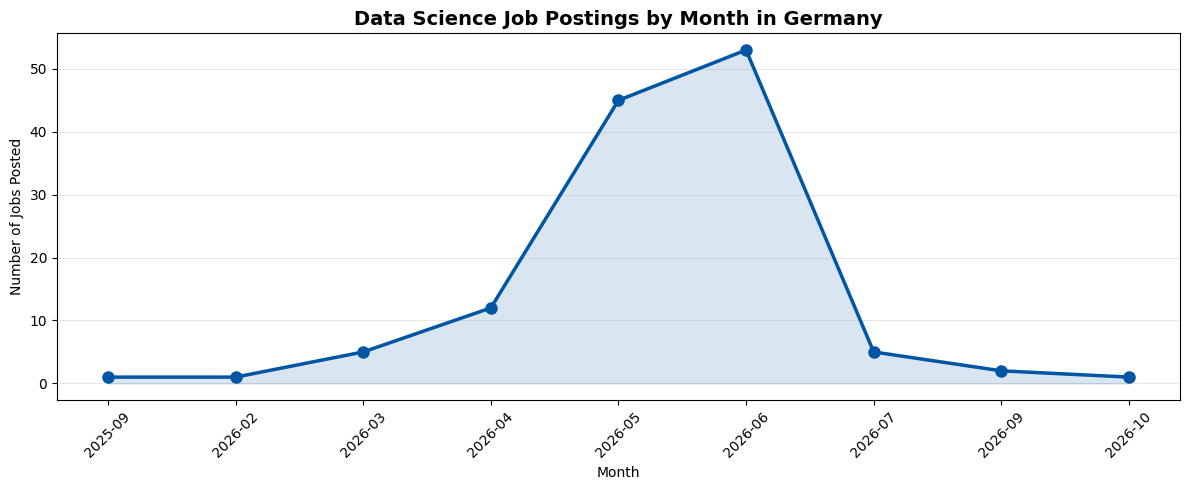


Most active month: 2026-06
Jobs that month: 53


In [10]:
# Cell 7 — Job Postings Over Time
plt.figure(figsize=(12, 5))

# Group by month
df['month'] = df['posted_date'].dt.to_period('M')
monthly_counts = df['month'].value_counts().sort_index()

plt.plot(monthly_counts.index.astype(str), monthly_counts.values,
         marker='o', linewidth=2.5, color='#0055A4', markersize=8)

plt.fill_between(monthly_counts.index.astype(str), monthly_counts.values,
                 alpha=0.15, color='#0055A4')

plt.title('Data Science Job Postings by Month in Germany', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Jobs Posted')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/jobs_over_time.png', dpi=150)
plt.show()

print(f"\nMost active month: {monthly_counts.idxmax()}")
print(f"Jobs that month: {monthly_counts.max()}")